# Logdet Method Profiling Across Matrix Sizes

This notebook profiles the runtime of different log-determinant strategies used in bayespecon.


The profiling matrices come from a regular polygon grid generated by the `bayespecon.dgp` module. Each size `n` is a grid side length producing an `n × n` rook-contiguity layout with `n²` spatial units; the spatial graph is built from the polygon GeoDataFrame returned by the DGP function.


Methods compared:

- `exact`: symbolic determinant route
- `eigenvalue`: spectral precompute route
- `grid_dense`: dense-grid + spline interpolation (was `dense_grid`/`grid`)
- `grid_sparse`: exact sparse-LU grid (legacy-style sparse-LU, was `sparse_grid`/`full`)
- `sparse_spline`: sparse-LU + spline interpolation (was `spline`)
- `trace_mc`: Monte Carlo trace approximation (was `mc`)
- `grid_ilu`: ILU-based approximate grid (was `ilu`/`ichol`)
- `chebyshev`: Chebyshev polynomial approximation via Clenshaw's algorithm (Pace & LeSage 2004)

For each matrix size, we report:

- **setup time**: build + compile callable logdet function
- **evaluation time**: average cost to evaluate at many rho values

In [1]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor
import pytensor.tensor as pt
from libpysal import graph

from bayespecon import dgp
from bayespecon.logdet import make_logdet_fn

In [2]:
def make_grid_w(n_side: int) -> np.ndarray:
    """Create a row-standardized rook-contiguity matrix from an n_side x n_side polygon grid.

    Uses ``dgp.simulate_sar`` with ``create_gdf=True`` to generate the polygon
    geometry, then builds a contiguity graph from the returned GeoDataFrame.
    """
    gdf = dgp.simulate_sar(n=n_side, create_gdf=True)
    W = (
        graph.Graph.build_contiguity(gdf, rook=True)
        .transform("r")
        .sparse.toarray()
        .astype(np.float64)
    )
    return W


def compile_logdet_callable(W: np.ndarray, method: str, rho_min: float, rho_max: float):
    """Return a compiled callable f(rho) and its setup time in seconds."""
    t0 = time.perf_counter()
    rho = pt.scalar("rho")
    expr = make_logdet_fn(W, method=method, rho_min=rho_min, rho_max=rho_max)(rho)
    fn = pytensor.function([rho], expr)
    setup_s = time.perf_counter() - t0
    return fn, setup_s


def bench_eval_seconds(fn, rhos: np.ndarray, repeats: int = 5) -> float:
    """Median per-call evaluation latency in microseconds."""
    run_times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for r in rhos:
            _ = fn(float(r))
        elapsed = time.perf_counter() - t0
        run_times.append(elapsed / len(rhos))
    return float(np.median(run_times))

In [8]:
@dataclass
class ProfileConfig:
    # Grid side lengths; obs count = n_side². e.g. 6→36, 9→81, 11→121, 13→169, 16→256.
    sizes: tuple[int, ...] = (10, 20, 25, 40, 50, 75)
    methods: tuple[str, ...] = (
        "exact",
        "eigenvalue",
        "grid_dense",
        "grid_sparse",
        "sparse_spline",
        "trace_mc",
        "grid_mc",
        "grid_ilu",
        "chebyshev",
        "trace_hutchpp",
    )
    method_max_n: dict = None
    eval_points: int = 80
    eval_repeats: int = 3
    seed: int = 2026

    def __post_init__(self):
        if self.method_max_n is None:
            self.method_max_n = {
                "exact": 20,
                "eigenvalue": 75,
                "grid_dense": 40,
                "grid_sparse": 75,
                "sparse_spline": 75,
                "trace_mc": 75,
                "grid_ilu": 75,
                "chebyshev": 75,
                "grid_mc": 75,
                "trace_hutchpp": 75,
            }


cfg = ProfileConfig()

# spline/mc are defined on nonnegative rho ranges; others can use symmetric ranges.
method_rho_bounds = {
    "exact": (-0.95, 0.95),
    "eigenvalue": (-0.95, 0.95),
    "grid_dense": (-0.95, 0.95),
    "grid_sparse": (-0.95, 0.95),
    "grid_ilu": (-0.95, 0.95),
    "sparse_spline": (1e-5, 0.95),
    "trace_mc": (1e-5, 0.95),
    "chebyshev": (-0.95, 0.95),
    "grid_mc": (1e-5, 0.95),
    "trace_hutchpp": (-0.95, 0.95),
}

results = []
skipped = []

for n in cfg.sizes:
    W = make_grid_w(n_side=n)
    print(f"Profiling n_side={n} ({n * n} obs)...")
    for method in cfg.methods:
        if n > cfg.method_max_n[method]:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": method,
                    "reason": "above method_max_n cap",
                }
            )
            continue

        rho_min, rho_max = method_rho_bounds[method]
        rho_grid = np.linspace(rho_min, rho_max, cfg.eval_points)

        try:
            fn, setup_s = compile_logdet_callable(
                W, method, rho_min=rho_min, rho_max=rho_max
            )
            eval_s = bench_eval_seconds(fn, rho_grid, repeats=cfg.eval_repeats)
            results.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": method,
                    "rho_min": rho_min,
                    "rho_max": rho_max,
                    "setup_ms": 1e3 * setup_s,
                    "eval_us": 1e6 * eval_s,
                }
            )
        except Exception as exc:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": method,
                    "reason": f"failed: {type(exc).__name__}: {exc}",
                }
            )

res = pd.DataFrame(results).sort_values(["method", "n_obs"]).reset_index(drop=True)
if not res.empty:
    res["total_ms"] = res["setup_ms"] + (res["eval_us"] * cfg.eval_points / 1e3)
res

Profiling n_side=10 (100 obs)...
Profiling n_side=20 (400 obs)...
Profiling n_side=25 (625 obs)...
Profiling n_side=40 (1600 obs)...
Profiling n_side=50 (2500 obs)...
Profiling n_side=75 (5625 obs)...


,n_side,n_obs,method,rho_min,rho_max,setup_ms,eval_us,total_ms
0,10,100,chebyshev,-0.95000,0.95,134.540083,2.990625,134.779333
1,20,400,chebyshev,-0.95000,0.95,234.093958,2.565625,234.299208
2,25,625,chebyshev,-0.95000,0.95,388.729625,3.285412,388.992458
3,40,1600,chebyshev,-0.95000,0.95,1570.391834,2.390625,1570.583084
4,50,2500,chebyshev,-0.95000,0.95,2073.743959,2.496350,2073.943667
5,75,5625,chebyshev,-0.95000,0.95,4782.109334,2.499475,4782.309292
6,10,100,eigenvalue,-0.95000,0.95,51.285958,3.383337,51.556625
7,20,400,eigenvalue,-0.95000,0.95,37.769708,4.638550,38.140792
8,25,625,eigenvalue,-0.95000,0.95,120.234417,5.372913,120.664250
9,40,1600,eigenvalue,-0.95000,0.95,1336.216625,9.336462,1336.963542


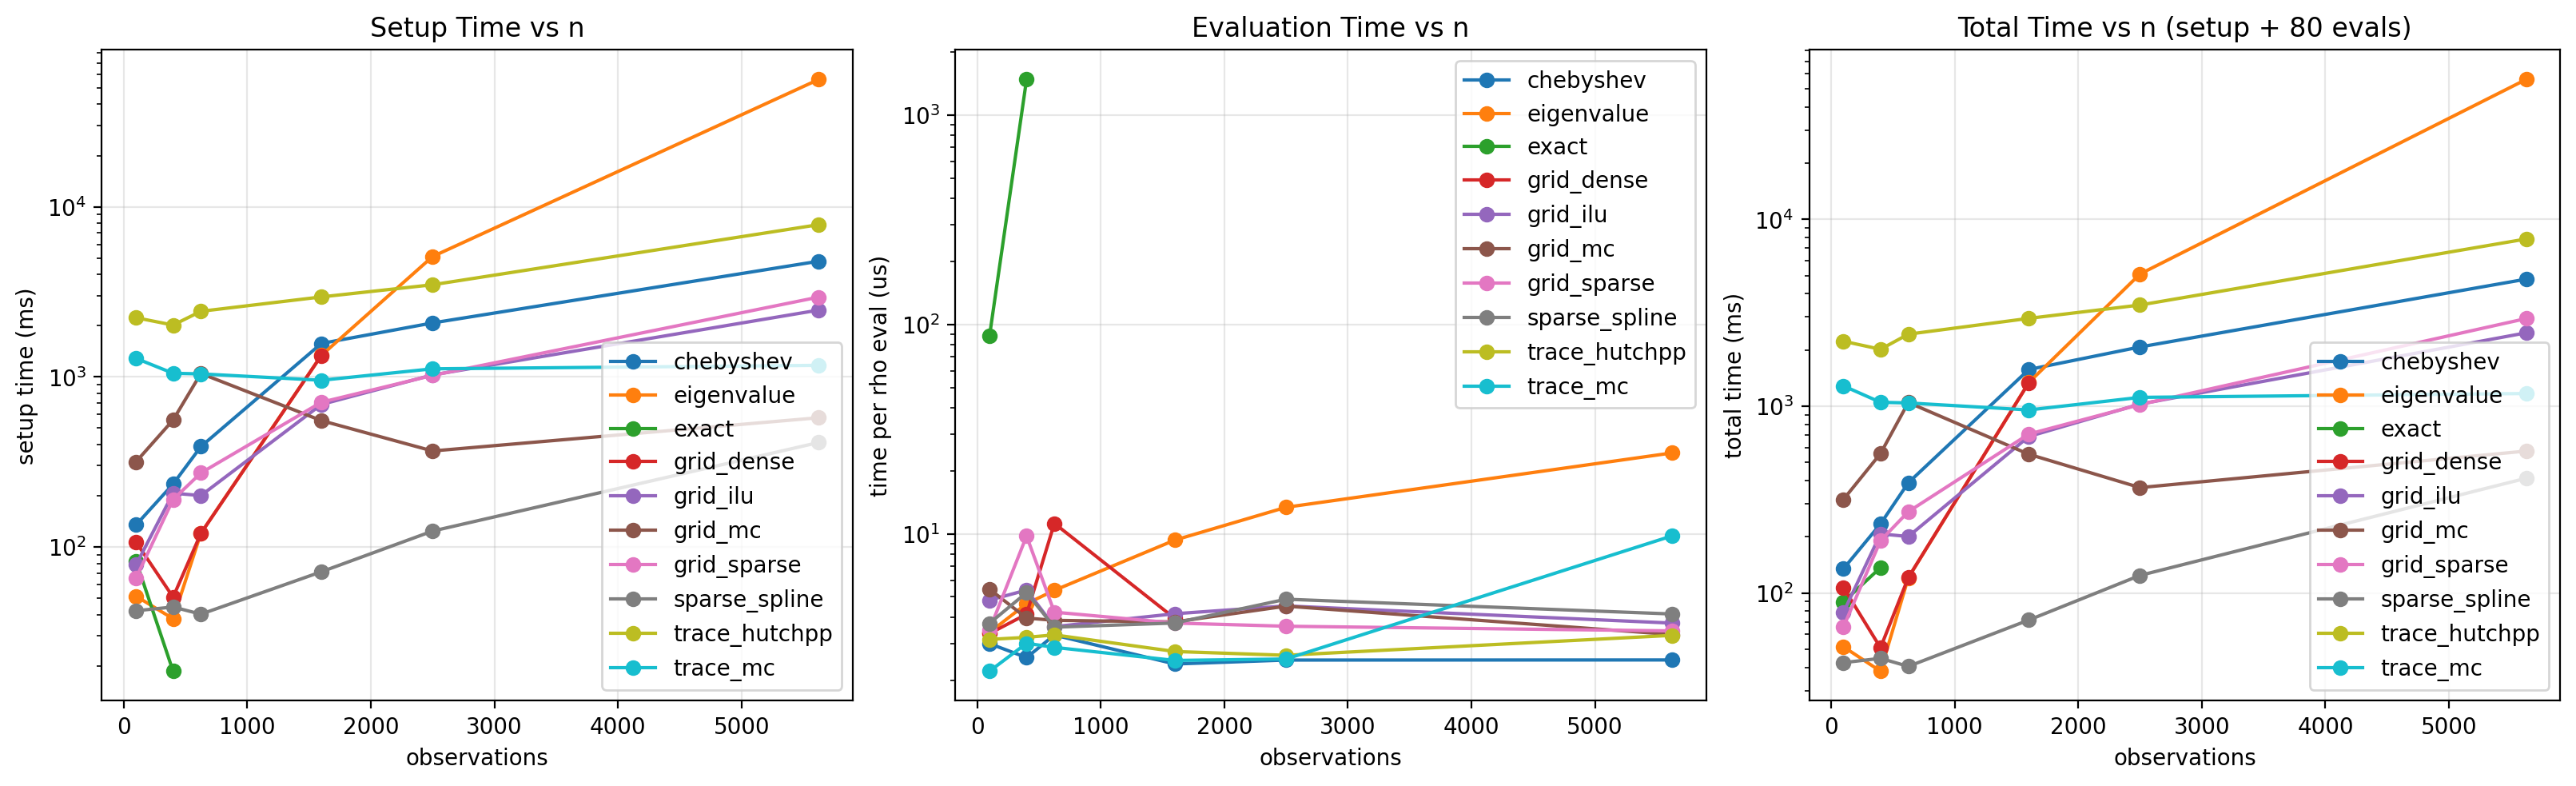

In [9]:
if res.empty:
    raise RuntimeError("No profiling results were generated.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for method, grp in res.groupby("method"):
    grp = grp.sort_values("n_obs")
    axes[0].plot(grp["n_obs"], grp["setup_ms"], marker="o", label=method)
    axes[1].plot(grp["n_obs"], grp["eval_us"], marker="o", label=method)
    axes[2].plot(grp["n_obs"], grp["total_ms"], marker="o", label=method)

axes[0].set_title("Setup Time vs n")
axes[0].set_xlabel("observations")
axes[0].set_ylabel("setup time (ms)")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Evaluation Time vs n")
axes[1].set_xlabel("observations")
axes[1].set_ylabel("time per rho eval (us)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

axes[2].set_title(f"Total Time vs n (setup + {cfg.eval_points} evals)")
axes[2].set_xlabel("observations")
axes[2].set_ylabel("total time (ms)")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.show()

In [10]:
summary = res.pivot_table(
    index="n_obs", columns="method", values=["setup_ms", "eval_us", "total_ms"]
).sort_index()
display(summary)

if skipped:
    skipped_df = (
        pd.DataFrame(skipped).sort_values(["n_side", "method"]).reset_index(drop=True)
    )
    print("Skipped combinations (due to safety caps or failures):")
    display(skipped_df)

eval_us                                                         \
method chebyshev eigenvalue        exact grid_dense  grid_ilu   grid_mc   
n_obs                                                                     
100     2.990625   3.383337    87.877087   3.340112  4.824475  5.444788   
400     2.565625   4.638550  1477.717713   4.134900  5.389588  3.961450   
625     3.285412   5.372913          NaN  11.216138  3.604687  3.863025   
1600    2.390625   9.336462          NaN   3.944788  4.154163  3.797925   
2500    2.496350  13.390625          NaN        NaN  4.527087  4.516675   
5625    2.499475  24.338550          NaN        NaN  3.747913  3.306250   

                                                          ...     total_ms  \
method grid_sparse sparse_spline trace_hutchpp  trace_mc  ...    chebyshev   
n_obs                                                     ...                
100       3.480738      3.739575      3.133325  2.208325  ...   134.779333   
400       9.765100      5.238025      3.204687  3.002088  ...   234.299208   
625       4.227075      3.583337      3.292700  2.870313  ...   388.992458   
1600      3.749488      3.752087      2.742700  2.485938  ...  1570.583084   
2500      3.620837      4.873438      2.630737  2.526037  ...  2073.943667   
5625      3.440100      4.142713      3.275525  9.781775  ...  4782.309292   

                                                                         \
method    eigenvalue       exact   grid_dense     grid_ilu      grid_mc   
n_obs                                                                     
100        51.556625   89.649750   107.016334    78.719042   316.844333   
400        38.140792  136.781042    50.924917   207.155625   557.535166   
625       120.664250         NaN   120.959666   200.549125  1046.179875   
1600     1336.963542         NaN  1335.479250   687.868042   552.790543   
2500     5096.199417         NaN          NaN  1025.964917   366.554709   
5625    56049.318668         NaN          NaN  2467.999250   574.763542   

                                                              
method  grid_sparse sparse_spline trace_hutchpp     trace_mc  
n_obs                                                         
100       65.819834     42.391124   2225.199375  1283.339083  
400      190.692417     44.696667   2014.908333  1048.559209  
625      272.341083     40.470917   2427.484041  1040.332250  
1600     708.899084     71.659626   2949.577708   954.361250  
2500    1019.802875    124.213250   3477.445334  1114.319125  
5625    2942.912875    411.166084   7845.588208  1168.435750  

[6 rows x 30 columns]

Skipped combinations (due to safety caps or failures):


,n_side,n_obs,method,reason
0,25,625,exact,above method_max_n cap
1,40,1600,exact,above method_max_n cap
2,50,2500,exact,above method_max_n cap
3,50,2500,grid_dense,above method_max_n cap
4,75,5625,exact,above method_max_n cap
5,75,5625,grid_dense,above method_max_n cap


## Coefficient and Fit-Time Comparison Across Logdet Methods

This section uses a regular polygon grid generated by `bayespecon.dgp` to simulate one SAR dataset, maps the simulated response, and estimates the same SAR model using each `logdet_method`.

We compare:

- posterior mean coefficients (`rho`, `beta_0`, `beta_1`, `beta_2`)
- total wall-clock time to estimate each model

To keep this section runnable in docs contexts, sampling is intentionally modest.


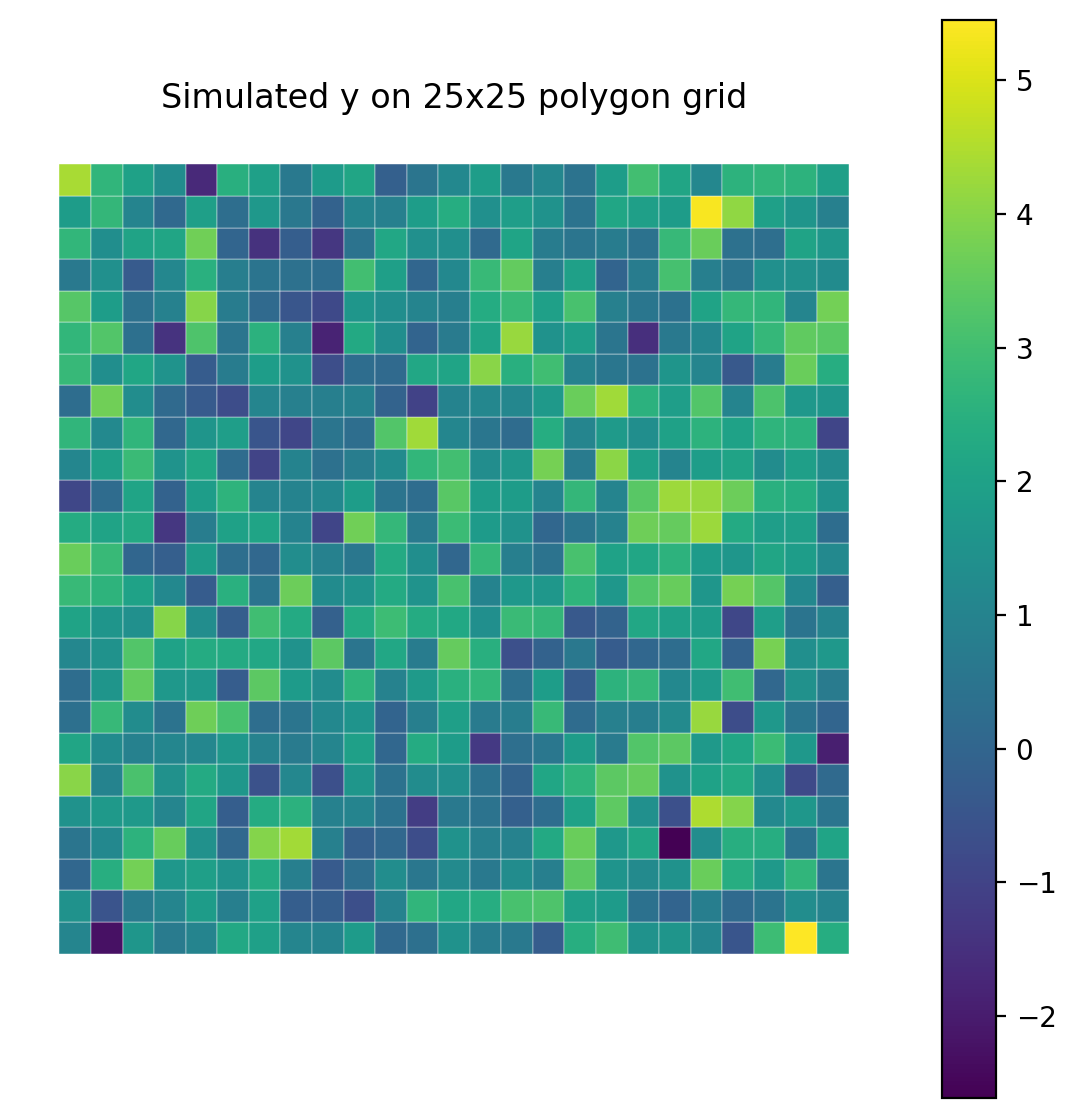

Estimating SAR with method=eigenvalue...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


Estimating SAR with method=sparse_spline...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...


Estimating SAR with method=trace_mc...


...

Estimating SAR with method=chebyshev...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


Estimating SAR with method=trace_xtrace...


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


,method,total_time_s,rho,beta_0,beta_1,beta_2,rho_true,abs_err_rho,beta_0_true,abs_err_beta_0,beta_1_true,abs_err_beta_1,beta_2_true,abs_err_beta_2,delta_vs_eigen_rho,delta_vs_eigen_beta_0,delta_vs_eigen_beta_1,delta_vs_eigen_beta_2
0,sparse_spline,1.965357,0.382676,0.882155,0.808407,-0.518637,0.35,0.032676,1.0,0.117845,0.8,0.008407,-0.5,0.018637,1.219458e-03,-2.364459e-03,-1.241932e-04,-3.838977e-04
1,eigenvalue,2.150392,0.381457,0.884519,0.808531,-0.518253,0.35,0.031457,1.0,0.115481,0.8,0.008531,-0.5,0.018253,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,grid_ilu,2.250140,0.382076,0.882487,0.807844,-0.520888,0.35,0.032076,1.0,0.117513,0.8,0.007844,-0.5,0.020888,6.188300e-04,-2.032753e-03,-6.876095e-04,-2.634321e-03
3,grid_mc,2.943181,0.382100,0.882973,0.809134,-0.520861,0.35,0.032100,1.0,0.117027,0.8,0.009134,-0.5,0.020861,6.434823e-04,-1.546014e-03,6.024639e-04,-2.607803e-03
4,chebyshev,3.487452,0.381457,0.884520,0.808532,-0.518253,0.35,0.031457,1.0,0.115480,0.8,0.008532,-0.5,0.018253,-2.763719e-07,4.041846e-07,2.492285e-08,-1.546428e-08
5,trace_xtrace,5.609410,0.381507,0.884446,0.808527,-0.518252,0.35,0.031507,1.0,0.115554,0.8,0.008527,-0.5,0.018252,4.969378e-05,-7.368190e-05,-4.357917e-06,1.277679e-06
6,trace_mc,8.255522,0.382005,0.882592,0.807850,-0.520890,0.35,0.032005,1.0,0.117408,0.8,0.007850,-0.5,0.020890,5.475654e-04,-1.927012e-03,-6.810664e-04,-2.636532e-03


In [11]:
from bayespecon import SAR


def simulate_sar_data(n_side: int = 16, seed: int = 2026):
    """Simulate SAR data on an n_side x n_side polygon grid using the DGP module."""
    rng = np.random.default_rng(seed)
    beta_true = np.array([1.0, 0.8, -0.5], dtype=np.float64)
    rho_true = 0.35
    sigma_true = 0.7

    gdf = dgp.simulate_sar(
        n=n_side,
        rho=rho_true,
        beta=beta_true,
        sigma=sigma_true,
        rng=rng,
        create_gdf=True,
    )
    # Keep the SAR parameterization consistent with model assumptions.
    W_graph = graph.Graph.build_contiguity(gdf, rook=True).transform("r")
    y = gdf["y"].to_numpy()
    X_cols = [c for c in gdf.columns if c.startswith("X_")]
    X = gdf[X_cols].to_numpy()
    return gdf, y, X, W_graph, rho_true, beta_true


def fit_sar_for_method(
    y,
    X,
    W,
    method: str,
    draws: int = 400,
    tune: int = 400,
    seed: int = 2026,
    rho_lower: float = 0.000001,
    rho_upper: float = 0.95,
):
    """Fit SAR with a specific logdet method and return posterior means + runtime."""
    t0 = time.perf_counter()

    model = SAR(
        y=y,
        X=X,
        W=W,
        logdet_method=method,
        priors={"rho_lower": rho_lower, "rho_upper": rho_upper},
    )
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=2,
        cores=1,
        random_seed=seed,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )

    elapsed_s = time.perf_counter() - t0
    beta_mean = idata.posterior["beta"].mean(("chain", "draw")).to_numpy()
    rho_mean = float(idata.posterior["rho"].mean(("chain", "draw")).to_numpy())

    return {
        "method": method,
        "total_time_s": elapsed_s,
        "rho": rho_mean,
        "beta_0": float(beta_mean[0]),
        "beta_1": float(beta_mean[1]),
        "beta_2": float(beta_mean[2]),
    }


methods_for_model = [
    "eigenvalue",
    "sparse_spline",
    "trace_mc",
    "grid_mc",
    "grid_ilu",
    "chebyshev",
    "trace_xtrace",
]
gdf_model, y_model, X_model, W_model, rho_true, beta_true = simulate_sar_data(n_side=25)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
gdf_model.plot(
    column="y", cmap="viridis", legend=True, linewidth=0.15, edgecolor="white", ax=ax
)
ax.set_title("Simulated y on 25x25 polygon grid")
ax.set_axis_off()
plt.show()

model_rows = []
for m in methods_for_model:
    print(f"Estimating SAR with method={m}...")
    try:
        model_rows.append(fit_sar_for_method(y_model, X_model, W_model, method=m))
    except Exception as exc:
        model_rows.append(
            {
                "method": m,
                "total_time_s": np.nan,
                "rho": np.nan,
                "beta_0": np.nan,
                "beta_1": np.nan,
                "beta_2": np.nan,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )

coef_compare = pd.DataFrame(model_rows)
coef_compare = coef_compare.sort_values("total_time_s", na_position="last").reset_index(
    drop=True
)

coef_compare["rho_true"] = rho_true
coef_compare["abs_err_rho"] = (coef_compare["rho"] - rho_true).abs()
for j, btrue in enumerate(beta_true):
    coef_compare[f"beta_{j}_true"] = btrue
    coef_compare[f"abs_err_beta_{j}"] = (coef_compare[f"beta_{j}"] - btrue).abs()

if "eigenvalue" in coef_compare["method"].values:
    base = coef_compare.loc[
        coef_compare["method"] == "eigenvalue", ["rho", "beta_0", "beta_1", "beta_2"]
    ].iloc[0]
    for col in ["rho", "beta_0", "beta_1", "beta_2"]:
        coef_compare[f"delta_vs_eigen_{col}"] = coef_compare[col] - base[col]

display(coef_compare)

## Notes

- `exact` is expected to scale poorly and is intentionally capped at smaller n in this notebook.
- `eigenvalue` usually has moderate setup cost and very fast repeated evaluations.
- `grid_dense` has an upfront grid-construction cost but can be competitive for repeated evaluation scenarios (was `dense_grid`/`grid`).
- `grid_sparse` and `sparse_spline` are sparse-LU variants inspired by the legacy toolbox routines (were `full` and `int`).
- `trace_mc` is stochastic and may vary slightly run-to-run unless random seeds are fixed.
- `grid_ilu` uses an ILU approximation that can trade precision for speed depending on sparsity (was `ilu`/`ichol`).
- `chebyshev` uses Chebyshev polynomial approximation via Clenshaw's algorithm (Pace & LeSage 2004). It pre-computes coefficients at Chebyshev nodes (O(n³) for eigenvalue path, O(R·n·m) for MC path) and then evaluates in O(m) per call. It supports negative rho ranges, unlike `sparse_spline` and `trace_mc`.
- **Parameter ranges:** `sparse_spline` and `trace_mc` are profiled on a nonnegative range (`rho in [1e-5, 0.95]`), while `exact`, `eigenvalue`, `grid_dense`, `grid_sparse`, `grid_ilu`, and `chebyshev` are profiled on a symmetric range (`rho in [-0.95, 0.95]`).
- Adjust `ProfileConfig.sizes` and `method_max_n` for deeper stress tests.

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draw

,method,ess_rho
0,eigenvalue,585.0
1,sparse_spline,580.0
2,trace_mc,517.0
3,grid_mc,497.0
4,grid_ilu,591.0
5,chebyshev,585.0
6,trace_xtrace,585.0


<Axes: title={'center': 'Effective Sample Size for rho by Logdet Method'}, xlabel='method', ylabel='ESS (rho)'>

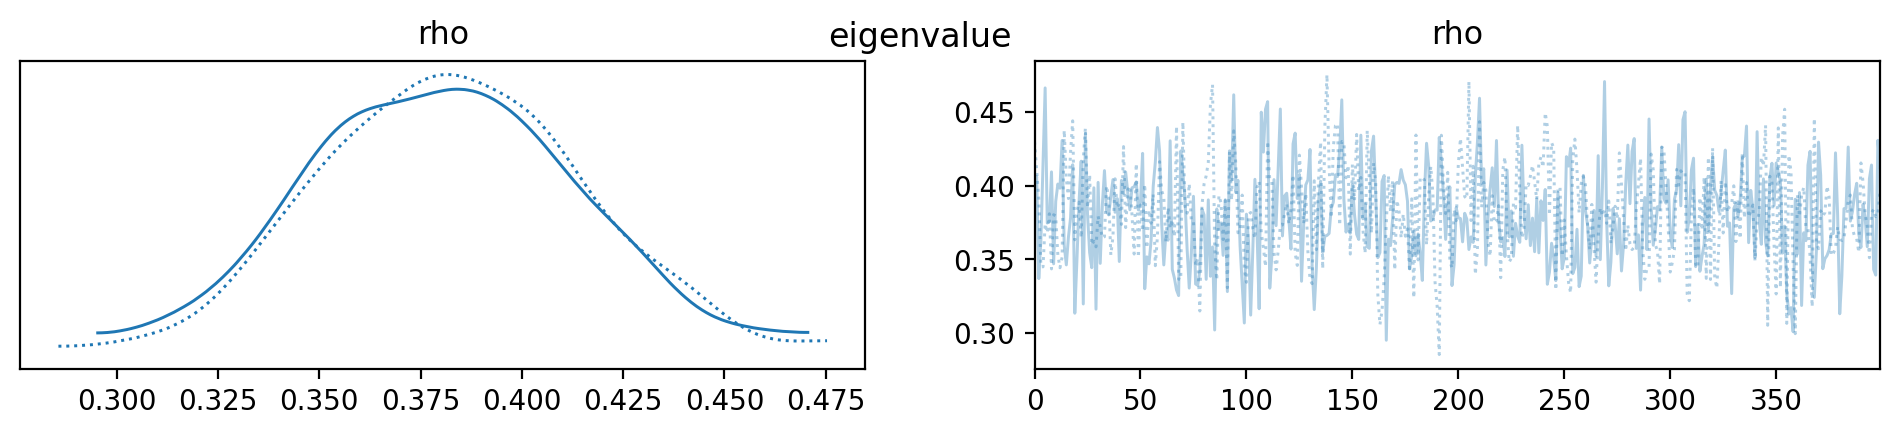

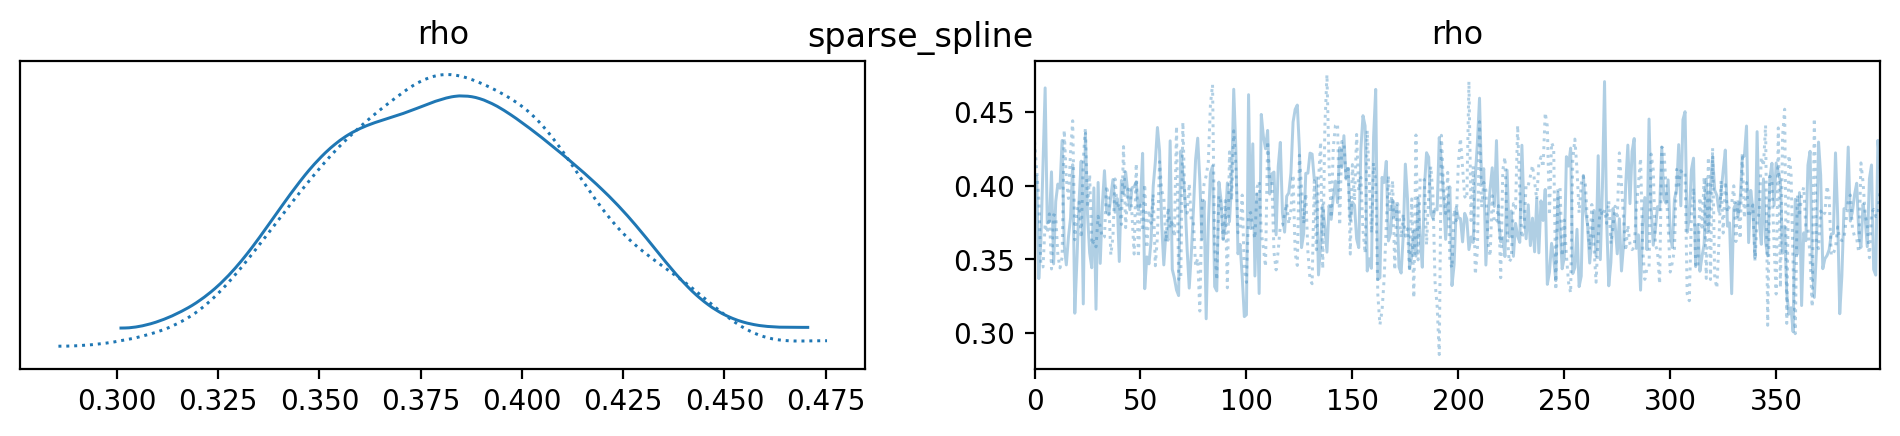

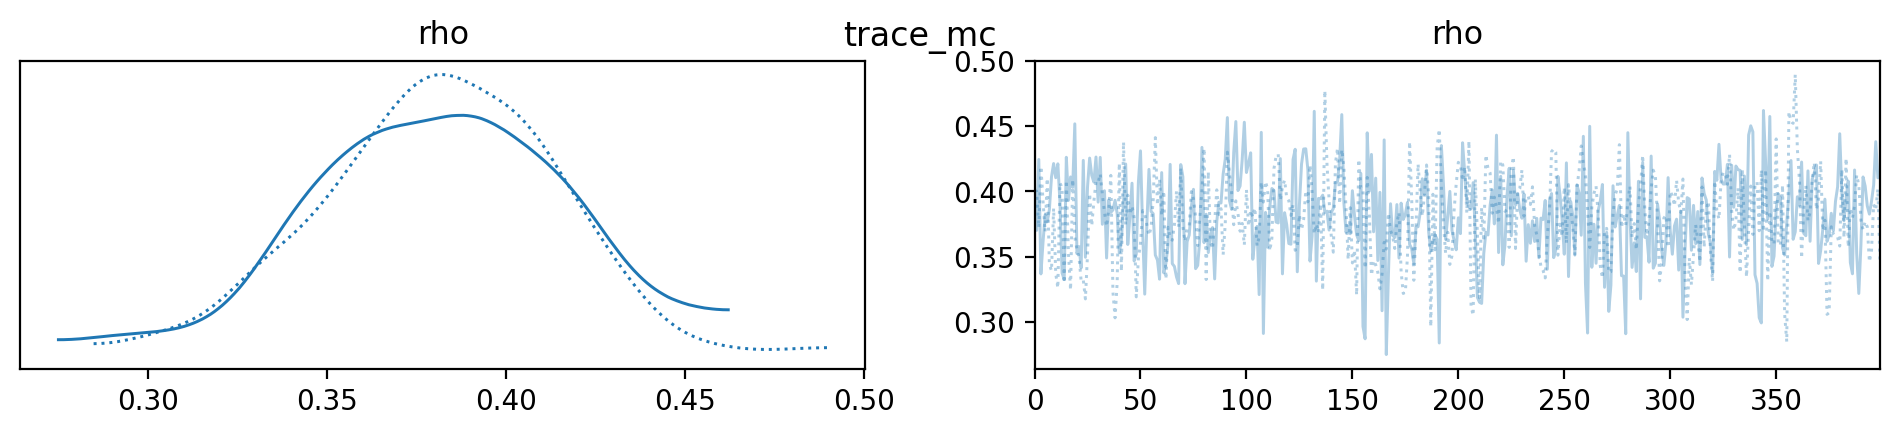

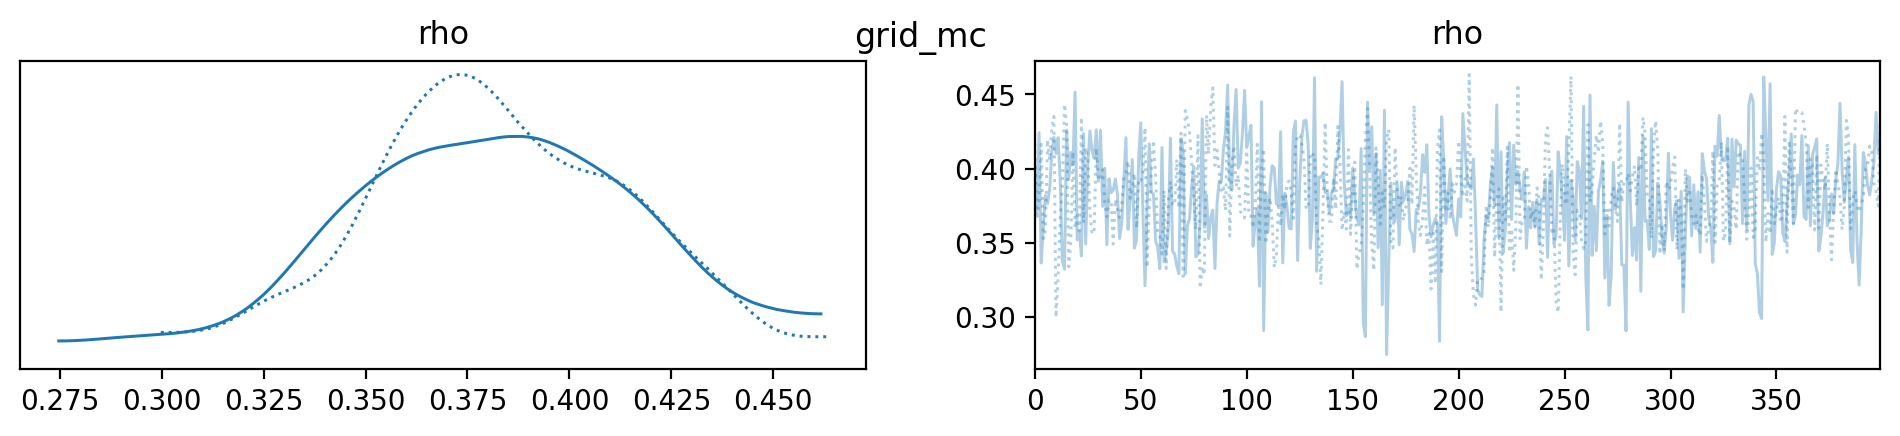

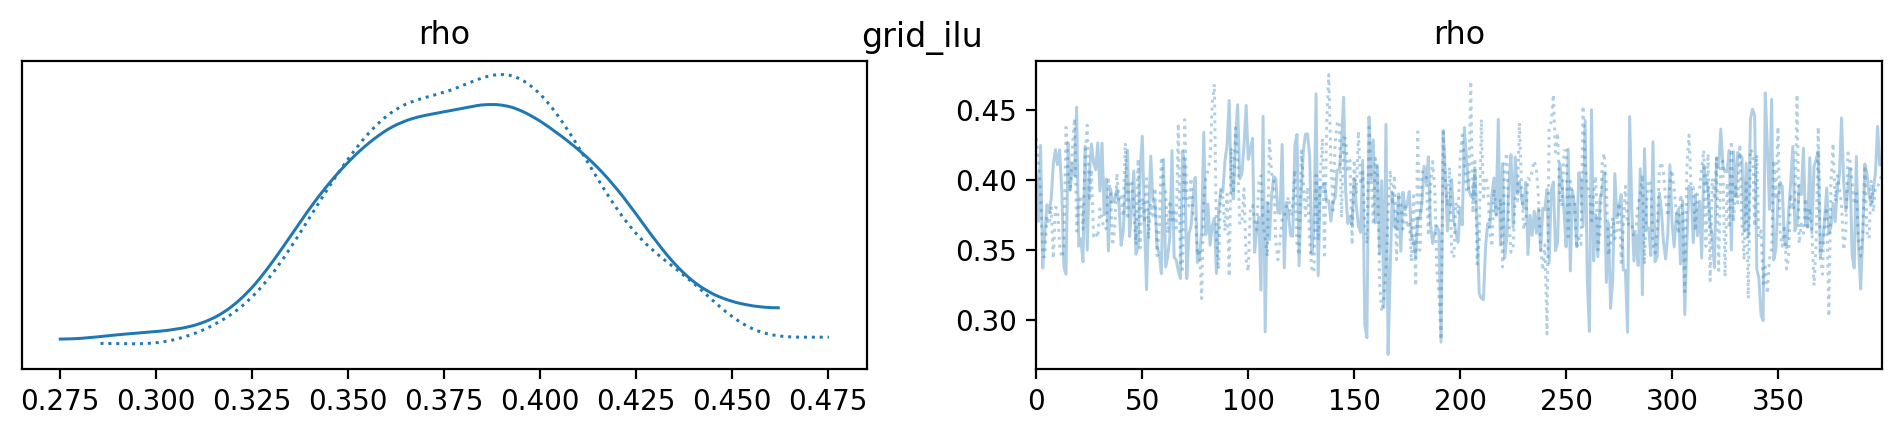

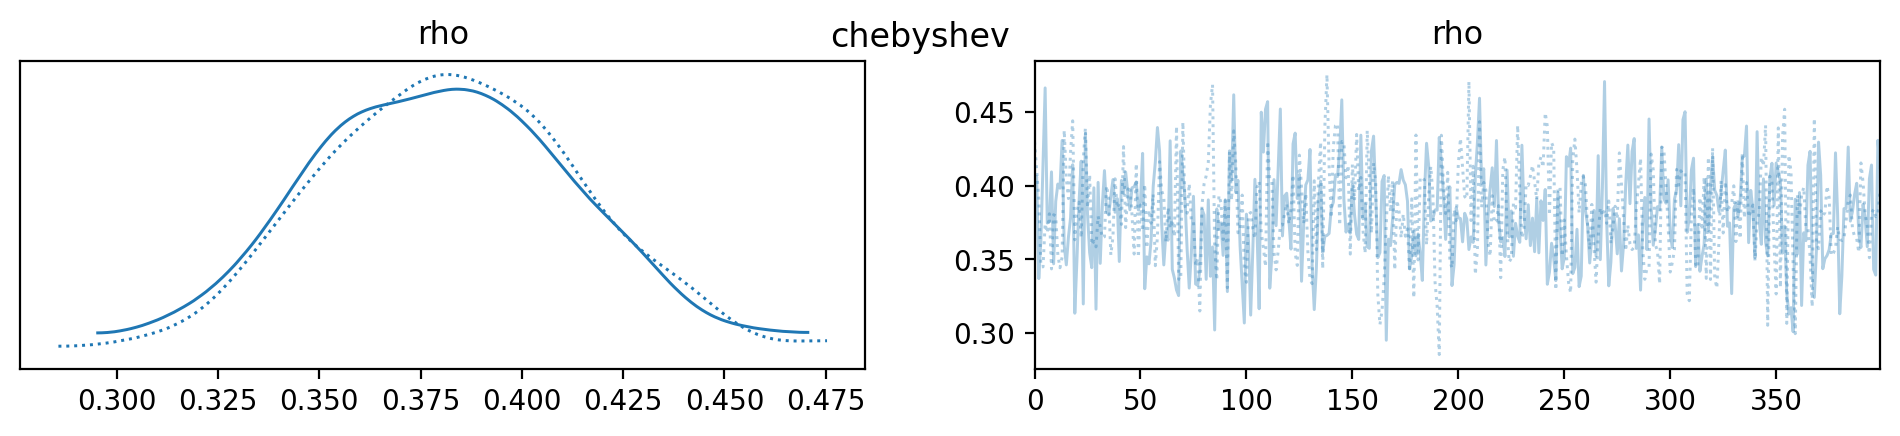

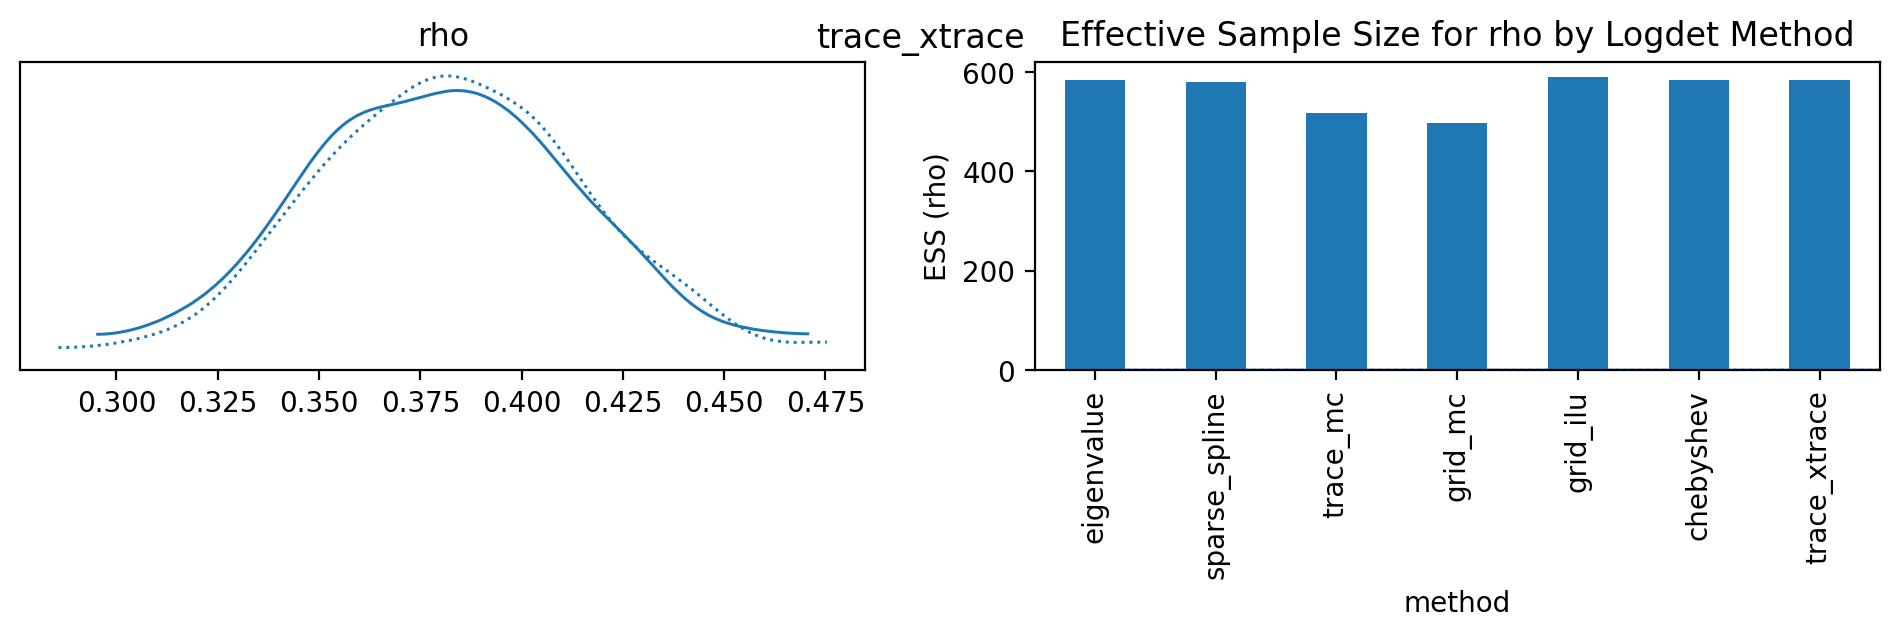

In [7]:
import arviz as az
import pandas as pd

# Assuming you have a list of inference data objects (idata) for each method,
# or you can refit/collect them as needed. If you only have the summary DataFrames,
# adapt the code to use those directly.

ess_rows = []
for i, m in enumerate(methods_for_model):
    model = SAR(
        y=y_model,
        X=X_model,
        W=W_model,
        logdet_method=m,
        priors={"rho_lower": 1e-5, "rho_upper": 0.95},
    )
    idata = model.fit(
        draws=400,
        tune=400,
        chains=2,
        cores=1,
        random_seed=2026,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )
    summary = az.summary(idata, var_names=["rho"])
    ess = summary.loc["rho", "ess_bulk"]
    ess_rows.append({"method": m, "ess_rho": ess})
    az.plot_trace(idata, var_names=["rho"], compact=True, legend=False)
    plt.suptitle(m)

ess_df = pd.DataFrame(ess_rows)
display(ess_df)

ess_df.set_index("method")["ess_rho"].plot.bar(
    ylabel="ESS (rho)", title="Effective Sample Size for rho by Logdet Method"
)

## Method selection policy

1. Default for most work

- Use chebyshev.
- Reason: good speed, stable behavior, and supports both negative and positive rho ranges.

2.Exploratory runs where speed is most important

- If rho is constrained to nonnegative values, use mc.
- Keep this for quick iteration, model search, and early diagnostics.

3. Deterministic interpolation alternative

- If rho is nonnegative and you want deterministic behavior, use spline.
- Only use when prior bounds are fully inside the interpolation interval.

4. Final reporting and publication runs

- Prefer chebyshev.
- If using mc or spline, validate against chebyshev on the same data and priors.

5. Guardrails
- If prior includes negative rho, do not use mc or spline.
- Avoid switching methods mid-comparison unless you explicitly document it.
- Record method choice and rho bounds in every benchmark or model report.


Suggested defaults by stage

Development: mc (nonnegative rho only), otherwise chebyshev.
Pre-final validation: chebyshev.
Final results: chebyshev, or mc/spline with chebyshev cross-check.